In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

#### Imports the required Python libraries for implementing the Sparse Autoencoder.

In [2]:
input_dim = 3072
hidden_dim = 512
batch_size = 128
learning_rate = 0.001
epochs = 20

# sparsity parameters
rho = 0.05           # desired sparsity
beta = 1e-3          # sparsity penalty weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


>Preprocesses the CIFAR-10 images by converting them into tensors and normalizing the pixel values.

>Loads the CIFAR-10 dataset, separating the data into training data and testing data.

>Automatically downloads the dataset if the dataset is not already available in the system.

>Uses DataLoader to divide the dataset into batches so the model can process images efficiently during training and testing.

>Shuffles the training data to help the model learn better, while testing data remains unshuffled for proper evaluation of model performance.

In [4]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, hidden_dim),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded


>Defines a Sparse Autoencoder model using PyTorch by inheriting from nn.Module.

>Encoder compresses the input from 3072 to 512, learning important features of the data.

>Linear layers and ReLU activation help the model learn complex patterns.

>Sigmoid activation keeps the output values between 0 and 1.

>Decoder reconstructs the compressed representation back to the original input size (3072).

>Forward function passes the input through the encoder and decoder to produce the encoded features and reconstructed output.

In [5]:
def sparsity_loss(rho, rho_hat):

    rho_hat = torch.mean(rho_hat, dim=0)

    kl_div = rho * torch.log(rho / (rho_hat + 1e-8)) + \
             (1 - rho) * torch.log((1 - rho) / (1 - rho_hat + 1e-8))

    return torch.sum(kl_div)



>Defines a sparsity loss function used in the Sparse Autoencoder.

>Calculates the average activation (rho_hat) of hidden neurons.

>Uses KL Divergence to measure the difference between the desired sparsity (rho) and the actual neuron activation (rho_hat).

>Encourages most neurons to remain inactive, allowing only a few neurons to activate.

>Returns the sparsity penalty, which is added to the reconstruction loss during training.

In [6]:
model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)



>MSELoss is used as the loss function to measure the difference between the original image and the reconstructed image.

>Adam optimizer is used to update the model weights during training using the specified learning rate.

In [8]:
for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()

        encoded, decoded = model(images)

        recon_loss = criterion(decoded, images)

        sparse_penalty = sparsity_loss(rho, encoded)

        loss = recon_loss + beta * sparse_penalty

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")



Epoch [1/20], Loss: 65.2832
Epoch [2/20], Loss: 64.5406
Epoch [3/20], Loss: 63.9849
Epoch [4/20], Loss: 63.5197
Epoch [5/20], Loss: 63.0546
Epoch [6/20], Loss: 62.6948
Epoch [7/20], Loss: 62.3884
Epoch [8/20], Loss: 62.1263
Epoch [9/20], Loss: 61.8524
Epoch [10/20], Loss: 61.6435
Epoch [11/20], Loss: 61.4274
Epoch [12/20], Loss: 61.2776
Epoch [13/20], Loss: 61.0937
Epoch [14/20], Loss: 60.9335
Epoch [15/20], Loss: 60.7870
Epoch [16/20], Loss: 60.6902
Epoch [17/20], Loss: 60.5535
Epoch [18/20], Loss: 60.4574
Epoch [19/20], Loss: 60.3489
Epoch [20/20], Loss: 60.2683


>Runs the training process for multiple epochs.

>Loads images in batches and flattens them for the autoencoder input.

>Passes images through the model to get encoded and reconstructed outputs.

>Calculates reconstruction loss and sparsity penalty.

>Updates the model weights using backpropagation.

>Prints the loss for each epoch to monitor training progress.

In [9]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, decoded = model(images)

        loss = criterion(decoded, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss)



Test Reconstruction Loss: 12.060469940304756


>Sets the model to evaluation mode.

>Disables gradient calculation during testing.

>Loads test images in batches and flattens them.

>Passes images through the model to get reconstructed outputs.

>Calculates reconstruction loss for the test data.

>Prints the total test reconstruction loss to evaluate the model.

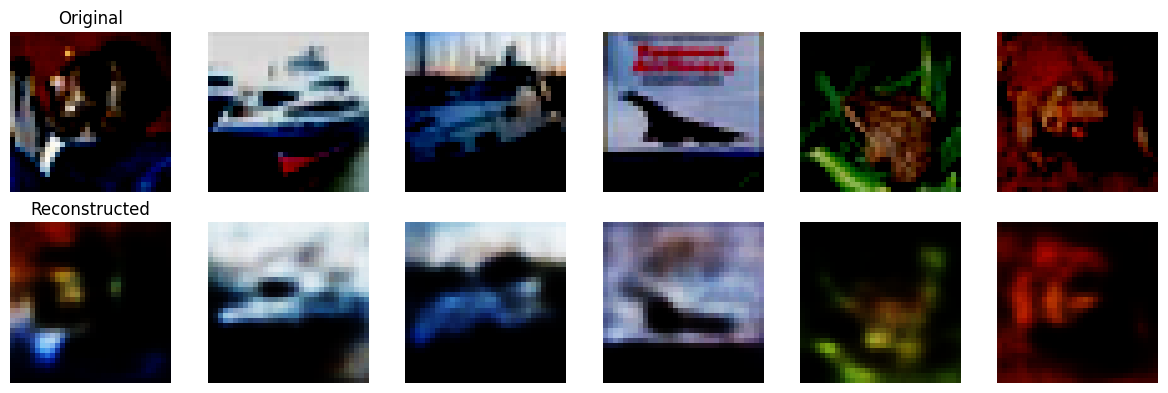

In [12]:
def show_images(original, reconstructed):

    # Detach tensors from gradient computation
    original = original.detach().cpu().view(-1, 3, 32, 32)
    reconstructed = reconstructed.detach().cpu().view(-1, 3, 32, 32)

    fig, axes = plt.subplots(2, 6, figsize=(12,4))

    for i in range(6):

        # Convert tensor → numpy
        orig = original[i].permute(1,2,0).numpy()
        recon = reconstructed[i].permute(1,2,0).numpy()

        # Clip pixel values to valid range
        orig = orig.clip(0,1)
        recon = recon.clip(0,1)

        # Display original image
        axes[0,i].imshow(orig)
        axes[0,i].axis("off")

        # Display reconstructed image
        axes[1,i].imshow(recon)
        axes[1,i].axis("off")

    axes[0,0].set_title("Original")
    axes[1,0].set_title("Reconstructed")

    plt.tight_layout()
    plt.show()



# GET SAMPLE IMAGES FROM TEST DATA


dataiter = iter(test_loader)
images, labels = next(dataiter)

# Flatten images for the autoencoder
images = images.view(images.size(0), -1).to(device)

# Pass through the model
encoded, reconstructed = model(images)

# Show comparison
show_images(images[:6], reconstructed[:6])

>Defines a function to display original and reconstructed images.

>Reshapes and converts tensors into image format for visualization.

>Shows original images in the first row and reconstructed images in the second row.

>Loads sample images from the test dataset and passes them through the model.

>Displays the comparison between original and reconstructed images.